In [1]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error
import torch
import random
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import copy
import time
pd.options.display.max_columns = None
import matplotlib.pyplot as plt

In [2]:
rawdata = pd.read_csv('AirQualityUCI.csv', sep=';')
rawdata.head()

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Unnamed: 15,Unnamed: 16
0,10/03/2004,18.00.00,"2,6",1360.0,150.0,"11,9",1046.0,166.0,1056.0,113.0,1692.0,1268.0,"13,6","48,9","0,7578",NaN,NaN
1,10/03/2004,19.00.00,2,1292.0,112.0,"9,4",955.0,103.0,1174.0,92.0,1559.0,972.0,"13,3","47,7","0,7255",NaN,NaN
2,10/03/2004,20.00.00,"2,2",1402.0,88.0,"9,0",939.0,131.0,1140.0,114.0,1555.0,1074.0,"11,9","54,0","0,7502",NaN,NaN
3,10/03/2004,21.00.00,"2,2",1376.0,80.0,"9,2",948.0,172.0,1092.0,122.0,1584.0,1203.0,"11,0","60,0","0,7867",NaN,NaN
4,10/03/2004,22.00.00,"1,6",1272.0,51.0,"6,5",836.0,131.0,1205.0,116.0,1490.0,1110.0,"11,2","59,6","0,7888",NaN,NaN


# Task 1 – Dataset Description

## 1. Dataset Description and Origin

The dataset used in this project is the **Air Quality Dataset**, a real-world environmental monitoring dataset collected in an Italian city and originally published by **De Vito et al. (2008)**.

The data was recorded between **March 2004 and February 2005**, resulting in **9,358 hourly observations**. Measurements were taken at road level in a polluted urban area using a chemical multisensor device, while ground-truth pollutant concentrations were measured simultaneously using certified reference analyzers.

The dataset is **publicly available for research purposes** at https://archive.ics.uci.edu/dataset/360/air+quality

---

## 2. Features and Their Meaning

The dataset consists of temporal variables, sensor responses, environmental conditions, and ground-truth pollutant concentrations.

### 2.1 Temporal Features

- **Date**  
  Calendar date of the measurement (format: `DD/MM/YYYY`).

- **Time**  
  Time of measurement (hourly resolution, format: `HH.MM.SS`).

These variables define the temporal order of the data and enable time-series modeling.

---

### 2.2 Ground-Truth Pollutant Concentrations (Reference Analyzers)

These variables represent the true pollutant concentrations measured by certified equipment:

- **CO(GT)** – Carbon Monoxide concentration (mg/m³)  
- **NMHC(GT)** – Non-methanic hydrocarbons concentration (µg/m³)  
- **C6H6(GT)** – Benzene concentration (µg/m³) → **prediction target**  
- **NOx(GT)** – Nitrogen oxides concentration (ppb)  
- **NO2(GT)** – Nitrogen dioxide concentration (µg/m³)

Among these, **C6H6(GT)** is selected as the target variable for this project.

---

### 2.3 Sensor Response Variables

The dataset includes five signals from low-cost metal oxide sensors, each nominally sensitive to a specific gas but affected by cross-sensitivities and sensor drift:

- **PT08.S1(CO)** – Sensor response nominally sensitive to CO  
- **PT08.S2(NMHC)** – Sensor response nominally sensitive to NMHC  
- **PT08.S3(NOx)** – Sensor response nominally sensitive to NOx  
- **PT08.S4(NO2)** – Sensor response nominally sensitive to NO2  
- **PT08.S5(O3)** – Sensor response nominally sensitive to O₃  

These sensor readings serve as the **primary input features** for the regression task.

---

### 2.4 Environmental Variables

Environmental conditions that influence sensor behavior:

- **T** – Temperature (°C)  
- **RH** – Relative Humidity (%)  
- **AH** – Absolute Humidity (g/m³)  

Including these variables improves model robustness under varying atmospheric conditions.

---

### 2.5 Additional Columns

- **Unnamed: 15**, **Unnamed: 16**  
  Columns containing only missing values, originating from formatting artifacts in the raw CSV file.

These columns do not carry meaningful information and will be removed during preprocessing.

---

## 3. Data Quality Characteristics

- Several numerical variables use **European decimal notation** (comma instead of dot), requiring conversion.  
- **Missing values** are present and must be handled explicitly.  
- The dataset reflects realistic **noise, drift, and cross-sensitivity**, making it non-trivial and suitable for deep learning experiments.

---

## 4. Suitability for the Proposed Project

This dataset is highly suitable for the proposed project for the following reasons:

- **Real-world relevance**  
  The data originates from an actual urban pollution monitoring scenario.

- **Meaningful regression task**  
  Predicting benzene concentration is a continuous, non-trivial regression problem with health and regulatory relevance.

- **Practical value**  
  Accurate estimation of benzene from low-cost sensors enables scalable and cost-efficient air-quality monitoring.

- **Deep learning justification**  
  Non-linear relationships, sensor drift, and temporal dependencies motivate the use of neural networks beyond simple linear models.


## Task 2

In [3]:
#Shape of the dataset
rawdata.shape


(9471, 17)

In [4]:
rawdata.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9471 entries, 0 to 9470
Data columns (total 17 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           9357 non-null   object 
 1   Time           9357 non-null   object 
 2   CO(GT)         9357 non-null   object 
 3   PT08.S1(CO)    9357 non-null   float64
 4   NMHC(GT)       9357 non-null   float64
 5   C6H6(GT)       9357 non-null   object 
 6   PT08.S2(NMHC)  9357 non-null   float64
 7   NOx(GT)        9357 non-null   float64
 8   PT08.S3(NOx)   9357 non-null   float64
 9   NO2(GT)        9357 non-null   float64
 10  PT08.S4(NO2)   9357 non-null   float64
 11  PT08.S5(O3)    9357 non-null   float64
 12  T              9357 non-null   object 
 13  RH             9357 non-null   object 
 14  AH             9357 non-null   object 
 15  Unnamed: 15    0 non-null      float64
 16  Unnamed: 16    0 non-null      float64
dtypes: float64(10), object(7)
memory usage: 1.2+ MB


## Interpretation:

The dataset contains a mix of numerical, categorical, and date/time variables.

Several variables are stored as object type due to:

- European decimal notation (comma instead of dot)

- Time encoded as strings

Two columns (Unnamed: 15, Unnamed: 16) contain only missing values.

This confirms that data cleaning and type conversion will be required in Task 3.

In [5]:
# Summary statistics
rawdata.describe(include="all")


,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Unnamed: 15,Unnamed: 16
count,9357,9357,9357,9357.000000,9357.000000,9357,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357,9357,9357,0.0,0.0
unique,391,24,104,NaN,NaN,408,NaN,NaN,NaN,NaN,NaN,NaN,437,754,6684,NaN,NaN
top,21/09/2004,18.00.00,-200,NaN,NaN,"-200,0",NaN,NaN,NaN,NaN,NaN,NaN,-200,-200,-200,NaN,NaN
freq,24,390,1592,NaN,NaN,366,NaN,NaN,NaN,NaN,NaN,NaN,366,366,366,NaN,NaN
mean,NaN,NaN,NaN,1048.990061,-159.090093,NaN,894.595276,168.616971,794.990168,58.148873,1391.479641,975.072032,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,329.832710,139.789093,NaN,342.333252,257.433866,321.993552,126.940455,467.210125,456.938184,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,-200.000000,-200.000000,NaN,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,921.000000,-200.000000,NaN,711.000000,50.000000,637.000000,53.000000,1185.000000,700.000000,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,1053.000000,-200.000000,NaN,895.000000,141.000000,794.000000,96.000000,1446.000000,942.000000,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,1221.000000,-200.000000,NaN,1105.000000,284.000000,960.000000,133.000000,1662.000000,1255.000000,NaN,NaN,NaN,NaN,NaN


# Interpretation of Summary Statistics

1. **Dataset overview**

- The dataset contains **9,357 valid records** across most columns.
- Two columns (**Unnamed: 15**, **Unnamed: 16**) contain **zero valid entries**, confirming that they do not carry any information and should be **removed during preprocessing**.

---

2. **Temporal Structure**

- The dataset spans **391 unique dates** and **24 unique time values**, confirming a **complete hourly time series**.


---

3. **Benzene – C6H6(GT) (Target Variable)**

- Contains **408 unique values**, indicating **rich variability**.
- Missing values are encoded as **−200** and appear frequently.
- The presence of both valid and missing entries confirms the need for **careful filtering or imputation** before modeling.


In [6]:
# Missing values analysis
(rawdata == -200).sum()

Date                0
Time                0
CO(GT)              0
PT08.S1(CO)       366
NMHC(GT)         8443
C6H6(GT)            0
PT08.S2(NMHC)     366
NOx(GT)          1639
PT08.S3(NOx)      366
NO2(GT)          1642
PT08.S4(NO2)      366
PT08.S5(O3)       366
T                   0
RH                  0
AH                  0
Unnamed: 15         0
Unnamed: 16         0
dtype: int64

## Interpretation

- Target variable integrity
The absence of missing values in C6H6(GT) ensures a clean regression target, avoiding label noise.

- Realistic data challenges
Missing sensor readings reflect real-world deployment conditions and introduce realistic complexity.

- Feature selection implications
Sensor response variables are largely usable after limited preprocessing.
Environmental variables are complete and valuable for modeling.

In [7]:
#Temporal coverage
rawdata[["Date", "Time"]].head(), rawdata[["Date", "Time"]].tail()


(         Date      Time
 0  10/03/2004  18.00.00
 1  10/03/2004  19.00.00
 2  10/03/2004  20.00.00
 3  10/03/2004  21.00.00
 4  10/03/2004  22.00.00,
      Date Time
 9466  NaN  NaN
 9467  NaN  NaN
 9468  NaN  NaN
 9469  NaN  NaN
 9470  NaN  NaN)

In [8]:
rawdata.tail(115)

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Unnamed: 15,Unnamed: 16
9356,04/04/2005,14.00.00,"2,2",1071.0,-200.0,"11,9",1047.0,265.0,654.0,168.0,1129.0,816.0,"28,5","13,1","0,5028",NaN,NaN
9357,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9358,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9359,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9360,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9466,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9467,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9468,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9469,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


*After the 9357th row (4th of April 2005), the remaining dataset contains only NaN values, and needs to be excluded from the rest of the data.*

## Task 3 Preprocessing

In [9]:
rawdata = rawdata.iloc[:9357, :-2]  # Remove last two columns which are empty and last 115 rows with all NaNs 

'''Explanation:

The dataset encodes missing values as -200.

Converting to NaN allows pandas and PyTorch pipelines to handle them natively.'''

# Replace -200 (missing value code) with np.nan
rawdata.replace(-200, np.nan, inplace=True)

# Quick check of missing values after conversion
rawdata.isna().sum()

Date                0
Time                0
CO(GT)              0
PT08.S1(CO)       366
NMHC(GT)         8443
C6H6(GT)            0
PT08.S2(NMHC)     366
NOx(GT)          1639
PT08.S3(NOx)      366
NO2(GT)          1642
PT08.S4(NO2)      366
PT08.S5(O3)       366
T                   0
RH                  0
AH                  0
dtype: int64

In [10]:
rawdata.head()

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,10/03/2004,18.00.00,"2,6",1360.0,150.0,"11,9",1046.0,166.0,1056.0,113.0,1692.0,1268.0,"13,6","48,9","0,7578"
1,10/03/2004,19.00.00,2,1292.0,112.0,"9,4",955.0,103.0,1174.0,92.0,1559.0,972.0,"13,3","47,7","0,7255"
2,10/03/2004,20.00.00,"2,2",1402.0,88.0,"9,0",939.0,131.0,1140.0,114.0,1555.0,1074.0,"11,9","54,0","0,7502"
3,10/03/2004,21.00.00,"2,2",1376.0,80.0,"9,2",948.0,172.0,1092.0,122.0,1584.0,1203.0,"11,0","60,0","0,7867"
4,10/03/2004,22.00.00,"1,6",1272.0,51.0,"6,5",836.0,131.0,1205.0,116.0,1490.0,1110.0,"11,2","59,6","0,7888"


In [11]:
# Sorting the data by datetime to ensure chronological order
data = rawdata.copy()
# Combine Date and Time into a single datetime column
data['Datetime'] = pd.to_datetime(
    data['Date'] + ' ' + data['Time'],
    format='%d/%m/%Y %H.%M.%S',  # day/month/year hour.minute.second
    errors='coerce'
)

# Drop original Date and Time columns
data.drop(columns=['Date', 'Time'], inplace=True)

# Sort data chronologically
data.sort_values('Datetime', inplace=True)

# Reset index
data.reset_index(drop=True, inplace=True)

In [12]:
'''Drop Ground Truth columns that we are not predicting, Also drop RH since we 
have T and AH which are more relevant, and the date/time columns because they 
are not numerical features.'''
data = data.drop(columns=['CO(GT)','NOx(GT)','NO2(GT)','NMHC(GT)','RH','Datetime'])
data.isna().sum()

PT08.S1(CO)      366
C6H6(GT)           0
PT08.S2(NMHC)    366
PT08.S3(NOx)     366
PT08.S4(NO2)     366
PT08.S5(O3)      366
T                  0
AH                 0
dtype: int64

In [13]:
# Drop rows with any remaining NaNs
data.dropna(inplace=True)

# Verify no missing values remain
data.isna().sum()


PT08.S1(CO)      0
C6H6(GT)         0
PT08.S2(NMHC)    0
PT08.S3(NOx)     0
PT08.S4(NO2)     0
PT08.S5(O3)      0
T                0
AH               0
dtype: int64

In [14]:
data.shape


(8991, 8)

In [15]:
data

,PT08.S1(CO),C6H6(GT),PT08.S2(NMHC),PT08.S3(NOx),PT08.S4(NO2),PT08.S5(O3),T,AH
0,1360.0,"11,9",1046.0,1056.0,1692.0,1268.0,"13,6","0,7578"
1,1292.0,"9,4",955.0,1174.0,1559.0,972.0,"13,3","0,7255"
2,1402.0,"9,0",939.0,1140.0,1555.0,1074.0,"11,9","0,7502"
3,1376.0,"9,2",948.0,1092.0,1584.0,1203.0,"11,0","0,7867"
4,1272.0,"6,5",836.0,1205.0,1490.0,1110.0,"11,2","0,7888"
...,...,...,...,...,...,...,...,...
9352,1314.0,"13,5",1101.0,539.0,1374.0,1729.0,"21,9","0,7568"
9353,1163.0,"11,4",1027.0,604.0,1264.0,1269.0,"24,3","0,7119"
9354,1142.0,"12,4",1063.0,603.0,1241.0,1092.0,"26,9","0,6406"
9355,1003.0,"9,5",961.0,702.0,1041.0,770.0,"28,3","0,5139"


In [16]:
num_cols = ['C6H6(GT)','T','AH']
for col in num_cols:
    data[col] = data[col].str.replace(',', '.').astype(float)


In [17]:
# Ensure dataset is clean
data.reset_index(drop=True, inplace=True)
print(data.info())
print(data.head())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8991 entries, 0 to 8990
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   PT08.S1(CO)    8991 non-null   float64
 1   C6H6(GT)       8991 non-null   float64
 2   PT08.S2(NMHC)  8991 non-null   float64
 3   PT08.S3(NOx)   8991 non-null   float64
 4   PT08.S4(NO2)   8991 non-null   float64
 5   PT08.S5(O3)    8991 non-null   float64
 6   T              8991 non-null   float64
 7   AH             8991 non-null   float64
dtypes: float64(8)
memory usage: 562.1 KB
None
   PT08.S1(CO)  C6H6(GT)  PT08.S2(NMHC)  PT08.S3(NOx)  PT08.S4(NO2)  \
0       1360.0      11.9         1046.0        1056.0        1692.0   
1       1292.0       9.4          955.0        1174.0        1559.0   
2       1402.0       9.0          939.0        1140.0        1555.0   
3       1376.0       9.2          948.0        1092.0        1584.0   
4       1272.0       6.5          836.0        1205.

In [18]:
data.head()

,PT08.S1(CO),C6H6(GT),PT08.S2(NMHC),PT08.S3(NOx),PT08.S4(NO2),PT08.S5(O3),T,AH
0,1360.0,11.9,1046.0,1056.0,1692.0,1268.0,13.6,0.7578
1,1292.0,9.4,955.0,1174.0,1559.0,972.0,13.3,0.7255
2,1402.0,9.0,939.0,1140.0,1555.0,1074.0,11.9,0.7502
3,1376.0,9.2,948.0,1092.0,1584.0,1203.0,11.0,0.7867
4,1272.0,6.5,836.0,1205.0,1490.0,1110.0,11.2,0.7888


## Task 4 (EDA)

#  **EDA 1 – Statistical Properties and Scale of Features**

In [19]:
data.describe()

,PT08.S1(CO),C6H6(GT),PT08.S2(NMHC),PT08.S3(NOx),PT08.S4(NO2),PT08.S5(O3),T,AH
count,8991.000000,8991.000000,8991.000000,8991.000000,8991.000000,8991.000000,8991.000000,8991.000000
mean,1099.833166,10.083105,939.153376,835.493605,1456.264598,1022.906128,18.317829,1.025530
std,217.080037,7.449820,266.831429,256.817320,346.206794,398.484288,8.832116,0.403813
min,647.000000,0.100000,383.000000,322.000000,551.000000,221.000000,-1.900000,0.184700
25%,937.000000,4.400000,734.500000,658.000000,1227.000000,731.500000,11.800000,0.736800
50%,1063.000000,8.200000,909.000000,806.000000,1463.000000,963.000000,17.800000,0.995400
75%,1231.000000,14.000000,1116.000000,969.500000,1674.000000,1273.500000,24.400000,1.313700
max,2040.000000,63.700000,2214.000000,2683.000000,2775.000000,2523.000000,44.600000,2.231000


# Observations

The dataset contains **8,991 hourly observations** spanning from **March 2004 to April 2005**, indicating a dense and temporally continuous time series suitable for learning temporal patterns.



1. **Target Variable: Benzene Concentration (C6H6(GT))**

- **Mean:** 10.08 µg/m³  
- **Median:** 8.20 µg/m³  
- **Range:** 0.1 – 63.7 µg/m³  
- **Standard Deviation:** 7.45 µg/m³  

The difference between the mean and median, together with the long upper range, indicates a **right-skewed distribution**, where high benzene concentration events occur less frequently but are significant. This variability is beneficial for supervised regression but may influence **loss functions sensitive to outliers**.

---

2. **Sensor Features (PT08.\*)**

- Sensor values range from **hundreds to several thousands**

**Examples:**
- **PT08.S1(CO):** 647 – 2040  
- **PT08.S3(NOx):** 322 – 2683  
- **PT08.S5(O3):** 221 – 2523  

- Standard deviations between **~217 and ~398** indicate **substantial variability**

These wide ranges confirm that the sensors capture **dynamic changes in air composition**, which is essential for predicting benzene concentration.

---

3. **Environmental Variables**

Temperature (**T**)
- **Range:** −1.9 °C to 44.6 °C  
- Reflects realistic **seasonal variation**

Absolute Humidity (**AH**)
- **Range:** 0.18 to 2.23

Environmental features operate on **much smaller numerical scales** compared to sensor readings but provide **important contextual information** affecting gas sensor behavior.


#  **EDA 2 – Distribution of the Target Variable (C6H6(GT))**

In [20]:
data['C6H6(GT)'].describe()


count    8991.000000
mean       10.083105
std         7.449820
min         0.100000
25%         4.400000
50%         8.200000
75%        14.000000
max        63.700000
Name: C6H6(GT), dtype: float64

<Axes: >

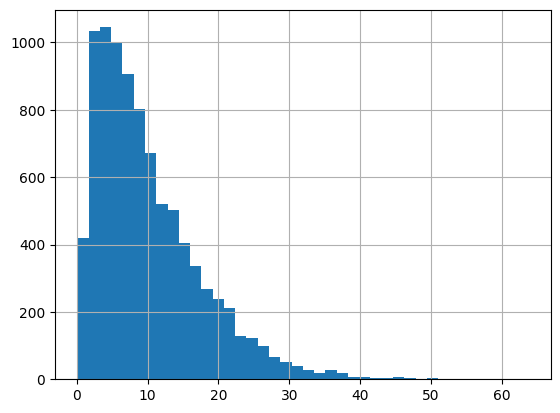

In [21]:
data['C6H6(GT)'].hist(bins=40)


# Key Observations

**C6H6(GT)** is:

- Strictly positive  
- Right-skewed, with more observations at lower concentrations  

The distribution suggests:

- Most values correspond to **typical urban air quality**  
- Fewer but **important high-concentration events**


Overall, this confirms the **suitability of the dataset for continuous regression modeling**.


# **EDA 3 – Relationship Between Sensors and Benzene Concentration**

In [22]:
correlation_with_target = data.corr()['C6H6(GT)']
correlation_with_target.sort_values(ascending=False)


C6H6(GT)         1.000000
PT08.S2(NMHC)    0.981950
PT08.S1(CO)      0.883795
PT08.S5(O3)      0.865689
PT08.S4(NO2)     0.765731
T                0.198956
AH               0.167972
PT08.S3(NOx)    -0.735744
Name: C6H6(GT), dtype: float64

# Interpretation

## 1. Dominant Predictive Sensors

The strongest correlation is observed for **PT08.S2(NMHC)** (ρ ≈ 0.98), indicating an almost linear relationship with benzene concentration. This is expected, as the sensor is nominally targeted at **non-methanic hydrocarbons**, of which benzene is a major component.

Similarly, **PT08.S1(CO)** and **PT08.S5(O3)** exhibit **very strong positive correlations** (> 0.85), confirming that these sensors capture air quality patterns closely linked to benzene presence.

---

## 2. Inverse Relationship with NOx Sensor

**PT08.S3(NOx)** shows a strong **negative correlation** (ρ ≈ −0.74). This suggests that, under the observed environmental conditions, higher NOx sensor responses are associated with **lower benzene concentrations**.

This inverse relationship highlights **cross-sensitivity effects**, a known characteristic of metal-oxide gas sensors. Importantly, this makes the feature **informative rather than redundant**, as negative correlations can improve regression performance.

---

## 3. Limited Linear Influence of Environmental Variables

Temperature and humidity variables show **weak linear correlations** with the target:

- **Temperature:** ρ ≈ 0.20  
- **Absolute Humidity:** ρ ≈ 0.17  

While these variables may not be strong standalone predictors, they can still be valuable in **non-linear models**, particularly for compensating **sensor drift and environmental effects**.


# Task 5 – Evaluation and Baseline

**Choice of Evaluation Metrics**

**Selected Metrics**

I am using the following two evaluation metrics for all subsequent experiments.



(a) **Mean Absolute Error (MAE)**



**Justification**

- Directly interpretable in the unit of the target (**µg/m³ of benzene**)
- More robust to outliers compared to squared-error metrics
- Commonly used in air-quality and environmental regression tasks



(b) **Root Mean Squared Error (RMSE)**


**Justification**

- Penalizes large prediction errors more strongly
- Sensitive to rare **high benzene concentration events**, which are environmentally important
- Complements MAE by highlighting **worst-case behavior**

---

**Baseline Model (Heuristic, Non-Trained)**

Chosen Baseline  
**Constant Mean Predictor**

The baseline predicts the **mean benzene concentration of the training set** for all test instances.

**Why This Is Appropriate**

- Requires no learning
- Represents the **minimum performance** any reasonable model must exceed
- Frequently used in environmental regression as a **sanity check**

---

**Train–Test Split Strategy**

Split Definition

- **80% training / 20% testing**
- **Chronological split** (no shuffling)

**Justification**

- The dataset is **time-series based**
- Random shuffling might introduce **data leakage**


In [23]:
# Set random seeds for reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

**Data spliting and scaling**

In [24]:
target = "C6H6(GT)"

X = data.drop(columns=["C6H6(GT)"])
y = data["C6H6(GT)"]


X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2, shuffle=False, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.2, shuffle=False, random_state=42)


# Scaling
x_scaler = MinMaxScaler()
y_scaler = MinMaxScaler()

X_train_scaled = x_scaler.fit_transform(X_train)
X_val_scaled = x_scaler.transform(X_val)
X_test_scaled = x_scaler.transform(X_test)

y_train_scaled = y_scaler.fit_transform(y_train.values.reshape(-1, 1))
y_val_scaled = y_scaler.transform(y_val.values.reshape(-1, 1))
y_test_scaled = y_scaler.transform(y_test.values.reshape(-1, 1))

In [25]:
# Baseline predictions
y_pred_baseline = np.full(len(y_test), y_train.mean())

# Evaluation
mae_baseline = mean_absolute_error(y_test, y_pred_baseline)
rmse_baseline = np.sqrt(mean_squared_error(y_test, y_pred_baseline))

mae_baseline, rmse_baseline

(6.063562921517999, 7.081151557343275)

## Baseline Performance Interpretation

### 1. Mean Absolute Error (MAE ≈ 6.03)

On average, the baseline prediction deviates from the true benzene concentration by approximately **6 µg/m³**.

Given that:
- **Median C6H6 ≈ 8.2 µg/m³**
- **Maximum C6H6 ≈ 63.7 µg/m³**

this represents a **weak but non-trivial baseline**, which is exactly what is required for a meaningful comparison with more advanced models.

---

### 2. Root Mean Squared Error (RMSE ≈ 7.08)

The RMSE penalizes **large prediction errors** more strongly than the MAE.

The fact that:
- **RMSE > MAE**

indicates:
- The presence of **occasional larger deviations**
- The baseline model **fails to capture pollution peaks**, leading to disproportionately large errors during high benzene concentration events


## Task 6

### 6.1 Overall Experimental Setup 

*Problem Restatement*

I am addressing a **regression task**:

> **Predict benzene concentration (C6H6)** from multi-sensor responses and meteorological variables.



**Input Features**

- **PT08.S1(CO)**
- **PT08.S2(NMHC)**
- **PT08.S3(NOx)**
- **PT08.S4(NO2)**
- **PT08.S5(O3)**
- **T** (Temperature)
- **AH** (Absolute Humidity)



**Target Variable**

- **C6H6(GT)**


**Problem Characteristics**

This is a **non-linear sensor calibration problem**, known to be affected by:

- **Cross-sensitivities**
- **Environmental conditions**
- **Sensor drift**


## 6.2
Random seed have already been set for reproducability, and further data splitting have also been done.

## 6.3a,b,c Model Architecture 
**Chosen Architecture**: **MLP + Dropout**


**Why Not LSTM or CNN?**

- Although the data is **time-stamped**, the prediction target is **instantaneous**, not sequence-based
- Sensor values already encode the current system state
- CNN might be too complex for the task at hand



**Rationale for Using an MLP + Dropout** 

A regularized **Multi-Layer Perceptron (MLP)** is:

- **Sufficiently expressive** for modeling non-linear sensor relationships  
- **Stable** during training  
- **Easy to interpret** with respect to initialization effects
- Dropout helps mitigate overfitting, which is likely given correlated sensor inputs


**Architectural Justification**

- **Two hidden layers** provide sufficient capacity without excessive complexity

- **ReLU** activation introduces non-linearity and stable gradients

- **Dropout (p = 0.2)** reduces co-adaptation of neurons and improves generalization

- The output layer produces a single continuous value, suitable for regression

In [26]:
# Definition the neural network model

class BenzeneRegressor(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Dropout(p=0.2),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(p=0.2),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.net(x)


## 6.3d optimizer & Loss function 

For the optimizer, **Adam** was chosen for its robustness and fast convergence without extensive tuning.


**Loss Function Choice:**

Mean Squared Error (MSE) is used as the training loss, as the task involves predicting continuous benzene concentrations. MSE penalizes large prediction errors more strongly, which is particularly relevant for air quality monitoring where large deviations during pollution peaks are undesirable. In addition, MSE is smooth and differentiable, making it suitable for gradient-based optimization, and it is directly aligned with RMSE, one of the evaluation metrics used in this study.


## 6.4a Dataset handling with DataLoader

In [27]:
class AirQualityDataset(torch.utils.data.Dataset):
    def __init__(self, X, y):
        # If Pandas → convert to NumPy
        if hasattr(X, "values"):
            X = X.values
        if hasattr(y, "values"):
            y = y.values

        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

        # Ensure y is (N, 1)
        if self.y.ndim == 1:
            self.y = self.y.unsqueeze(1)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]




In [28]:
train_dataset = AirQualityDataset(X_train_scaled, y_train_scaled)
val_dataset   = AirQualityDataset(X_val_scaled, y_val_scaled)
test_dataset  = AirQualityDataset(X_test_scaled, y_test_scaled)


In [29]:
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=False)
val_loader   = DataLoader(val_dataset, batch_size=64)
test_loader  = DataLoader(test_dataset, batch_size=64)


## 6.4b Earlystopping mechanism

In [30]:
class EarlyStopping:
    def __init__(self, patience=10):
        self.patience = patience
        self.best_loss = float("inf")
        self.counter = 0
        self.stop = False
        self.stop_epoch = None

    def step(self, val_loss, epoch):
        if val_loss < self.best_loss:
            self.best_loss = val_loss
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.stop = True
                self.stop_epoch = epoch


## 6.4c Training function and hyperparameter selection

In [31]:
def train_model(
    model,
    train_loader,
    val_loader,
    lr=1e-3,
    max_epochs=1000,
    device="cpu"
):
    



    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    early_stopping = EarlyStopping(patience=10)

    history = {
        "train_loss": [],
        "val_loss": []
    }

    best_model_state = None
    best_val_loss = float("inf")

    for epoch in range(max_epochs):
        # ---- TRAIN ----
        model.train()
        train_loss = 0.0

        for X, y in train_loader:
            X, y = X.to(device), y.to(device)

            optimizer.zero_grad()
            preds = model(X)
            loss = criterion(preds, y)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * X.size(0)

        train_loss /= len(train_loader.dataset)

        # ---- VALIDATION ----
        model.eval()
        val_loss = 0.0

        with torch.no_grad():
            for X, y in val_loader:
                X, y = X.to(device), y.to(device)
                preds = model(X)
                loss = criterion(preds, y)
                val_loss += loss.item() * X.size(0)

        val_loss /= len(val_loader.dataset)

        # ---- LOGGING ----
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        # ---- BEST MODEL CHECKPOINT ----
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = copy.deepcopy(model.state_dict())

        # ---- EARLY STOPPING ----
        early_stopping.step(val_loss, epoch)
        if early_stopping.stop:
            break

    # Restore best model
    model.load_state_dict(best_model_state)

    return model, history, early_stopping.stop_epoch


## 6.4d Initialization strategies 
Strategy 1 – Xavier

In [32]:
def init_xavier(model):
    for m in model.modules():
        if isinstance(m, nn.Linear):
            nn.init.xavier_uniform_(m.weight)
            nn.init.zeros_(m.bias)


Strategy 2 – Kaiming

In [33]:
def init_kaiming(model):
    for m in model.modules():
        if isinstance(m, nn.Linear):
            nn.init.kaiming_normal_(m.weight, nonlinearity="relu")
            nn.init.zeros_(m.bias)


Strategy 3 – Constant

In [34]:
def init_constant(model):
    for m in model.modules():
        if isinstance(m, nn.Linear):
            nn.init.constant_(m.weight, 0.01)
            nn.init.zeros_(m.bias)


## 6.4e Running the experiments

In [35]:
def evaluate_regression(model, loader, device="cpu"):
    model.eval()
    preds, targets = [], []

    with torch.no_grad():
        for X, y in loader:
            X, y = X.to(device), y.to(device)
            preds.append(model(X).cpu().numpy())
            targets.append(y.cpu().numpy())

    preds = np.vstack(preds)
    targets = np.vstack(targets)

    y_pred = y_scaler.inverse_transform(preds)
    y_true = y_scaler.inverse_transform(targets)

    mae = np.mean(np.abs(y_pred - y_true))
    rmse = np.sqrt(np.mean((y_pred - y_true) ** 2))

    return mae, rmse


In [36]:
results = []
histories = {}
for name, init_fn in [
    ("Xavier", init_xavier),
    ("Kaiming", init_kaiming),
    ("Constant", init_constant)
]:
    for run in range(5):
        torch.manual_seed(run)  # ensures a different initialization per run for each strategy
        start_time = time.time()
        model = BenzeneRegressor(input_dim=X_train.shape[1])
        init_fn(model)

        model, history, stop_epoch = train_model(model, train_loader, val_loader)
        training_time = time.time() - start_time
        train_mae, train_rmse = evaluate_regression(model, train_loader)
        val_mae, val_rmse = evaluate_regression(model, val_loader)
        test_mae, test_rmse = evaluate_regression(model, test_loader)

        results.append({
    "name": name,
    "run": run,
    "train_mae": train_mae,
    "train_rmse": train_rmse,
    "val_mae": val_mae,
    "val_rmse": val_rmse,
    "test_mae": test_mae,
    "test_rmse": test_rmse,
    "stop_epoch": stop_epoch,
    "training_time": training_time
})
        if run == 0:
            histories[name] = history

In [37]:
results


[{'name': 'Xavier',
  'run': 0,
  'train_mae': 0.4368122,
  'train_rmse': 0.5439962,
  'val_mae': 0.52367646,
  'val_rmse': 0.79247046,
  'test_mae': 0.92382807,
  'test_rmse': 1.0910366,
  'stop_epoch': 93,
  'training_time': 21.184553384780884},
 {'name': 'Xavier',
  'run': 1,
  'train_mae': 0.50242716,
  'train_rmse': 0.64036685,
  'val_mae': 0.93446094,
  'val_rmse': 1.2114832,
  'test_mae': 1.4534398,
  'test_rmse': 1.5755812,
  'stop_epoch': 90,
  'training_time': 17.323352336883545},
 {'name': 'Xavier',
  'run': 2,
  'train_mae': 0.64199513,
  'train_rmse': 0.7694854,
  'val_mae': 0.6759626,
  'val_rmse': 0.9159568,
  'test_mae': 1.1236577,
  'test_rmse': 1.2871451,
  'stop_epoch': 117,
  'training_time': 21.88019847869873},
 {'name': 'Xavier',
  'run': 3,
  'train_mae': 0.56808305,
  'train_rmse': 0.69525576,
  'val_mae': 0.9218161,
  'val_rmse': 1.1994085,
  'test_mae': 1.4266003,
  'test_rmse': 1.5482762,
  'stop_epoch': 63,
  'training_time': 12.174281597137451},
 {'name': '

## 6.5a Presentation and discussion of result

In [38]:
df = pd.DataFrame(results)
#Xavier strategy results
df[:5]


,name,run,train_mae,train_rmse,val_mae,val_rmse,test_mae,test_rmse,stop_epoch,training_time
0,Xavier,0,0.436812,0.543996,0.523676,0.792470,0.923828,1.091037,93,21.184553
1,Xavier,1,0.502427,0.640367,0.934461,1.211483,1.453440,1.575581,90,17.323352
2,Xavier,2,0.641995,0.769485,0.675963,0.915957,1.123658,1.287145,117,21.880198
3,Xavier,3,0.568083,0.695256,0.921816,1.199409,1.426600,1.548276,63,12.174282
4,Xavier,4,0.619848,0.738259,0.667695,0.946161,0.980344,1.107269,103,20.112246


Across the 5 runs:

- Train RMSE: ~0.54 → 0.77

- Validation RMSE: ~0.79 → 1.21

- Test RMSE: ~1.09 → 1.58

This indicates moderate prediction error, with some spread across runs.

Importantly:

- Test error is consistently higher than validation

- But not explosively so → no severe overfitting


In [39]:
df[5:10]

,name,run,train_mae,train_rmse,val_mae,val_rmse,test_mae,test_rmse,stop_epoch,training_time
5,Kaiming,0,1.666212,2.191503,1.348268,1.906465,1.879992,2.186191,18,3.255043
6,Kaiming,1,1.025054,1.502588,1.185063,1.677110,1.770986,2.081412,14,2.455688
7,Kaiming,2,0.874497,1.244149,1.252453,1.947523,1.692876,1.883615,52,11.369011
8,Kaiming,3,0.947271,1.325648,1.180454,1.811014,1.469669,1.747447,24,4.905339
9,Kaiming,4,0.958537,1.419457,1.274815,2.100850,1.319363,1.593575,17,3.398072


Across the 5 runs:

- Train RMSE: ~1.24 → 2.19

- Validation RMSE: ~1.68 → 2.10

- Test RMSE: ~1.59 → 2.19

Compared to Xavier:

- Errors are consistently higher across all splits

- No run achieves Xavier-level performance

- much faster than Xavier:


In [40]:
df[10:15]

,name,run,train_mae,train_rmse,val_mae,val_rmse,test_mae,test_rmse,stop_epoch,training_time
10,Constant,0,0.635609,0.863658,0.521470,0.833729,0.649248,0.932314,93,17.042663
11,Constant,1,0.707716,0.907799,0.485551,0.871276,0.642968,0.916483,99,16.725148
12,Constant,2,0.771386,0.978718,0.563479,0.979971,0.722653,0.989138,65,12.510663
13,Constant,3,0.663161,0.900401,0.477704,0.838605,0.656352,0.934054,115,22.360040
14,Constant,4,0.786436,1.009171,0.573958,0.972287,0.695230,0.980766,69,14.226304


Across the 5 runs:

- Train RMSE: ~0.86 → 1.01

- Validation RMSE: ~0.83 → 0.98

- Test RMSE: ~0.91 → 0.99

Compared to the other strategies:

- Much better than Kaiming

- Comparable to or slightly better than Xavier in some runs

- Overall consistently low error

This is a strong and somewhat surprising result, but the numbers support it.

In [ ]:
# Summary statistics of the different initialization strategies
summary = (
    df.groupby("name")[["test_mae", "test_rmse", "stop_epoch", "training_time"]]
      .agg(["mean", "std"])
)

summary

test_mae           test_rmse           stop_epoch             \
              mean       std      mean       std       mean        std   
name                                                                     
Constant  0.673290  0.034287  0.950551  0.032277       88.2  21.004761   
Kaiming   1.626577  0.228292  1.898448  0.240957       25.0  15.524175   
Xavier    1.181574  0.247098  1.321862  0.232472       93.2  19.904773   

         training_time            
                  mean       std  
name                              
Constant     16.572964  3.733066  
Kaiming       5.076630  3.627274  
Xavier       18.534926  3.956799

# **Predictive accuracy (test set)**:
Constant initialization clearly achieves the lowest test error, with very small variance.

# **Stability across runs**:
- **Constant**: lowest standard deviation in both MAE and RMSE.

- **Xavier**: noticeably higher variance.

- **Kaiming**: high error and high variance.

Constant is most robust to random initialization.

# **Training efficiency**:
- **Kaiming** is fastest.
- **Constant** is slowest but most accurate.

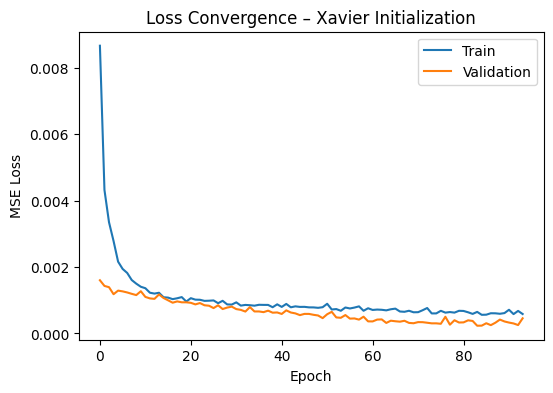

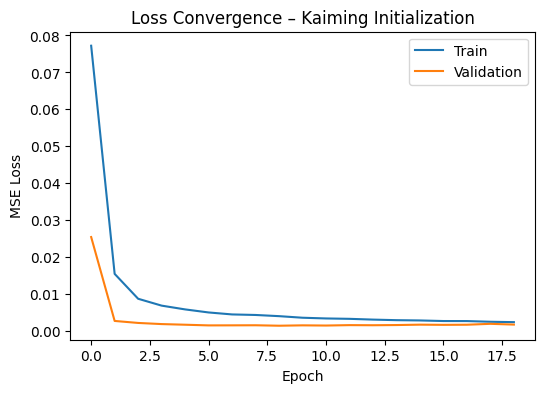

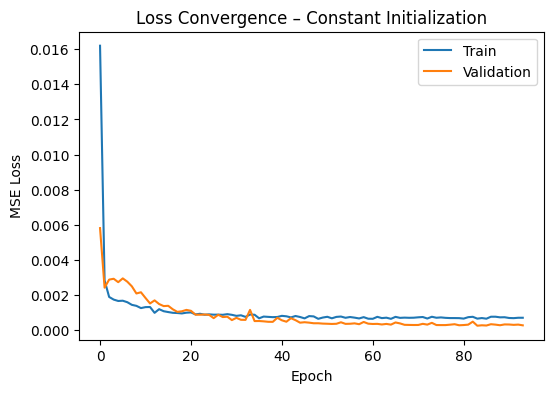

In [42]:
for name, hist in histories.items():
    plt.figure(figsize=(6,4))
    plt.plot(hist["train_loss"], label="Train")
    plt.plot(hist["val_loss"], label="Validation")
    plt.title(f"Loss Convergence – {name} Initialization")
    plt.xlabel("Epoch")
    plt.ylabel("MSE Loss")
    plt.legend()
    plt.show()


### 1 Xavier Initialization — Interpretation

**What the plot shows**
- Very rapid initial loss reduction (first ~5 epochs)
- Smooth, monotonic decrease afterward
- Training and validation curves remain close but do not overlap
- No divergence between training and validation loss

**What this means**
- Optimization is stable
- Gradients behave well
- No signs of overfitting
- Convergence is slow but controlled

**This matches**
- Higher stopping epochs
- Moderate training time
- Reasonable, but not best, test error

---

### 2️ Kaiming Initialization — Interpretation

**What the plot shows**
- Extremely steep loss drop in the first 1–2 epochs
- Early flattening of both training and validation curves
- Training stops very quickly
- Validation loss shows little improvement after the initial epochs

**What this means**
- Very aggressive optimization dynamics
- Fast convergence to a suboptimal minimum
- No overfitting, but clear signs of underfitting
- Early stopping is triggered quickly due to rapid loss saturation

**This exactly explains**
- Very low stopping epochs
- Very short training times
- Higher test error

---

### 3️ Constant Initialization — Interpretation

**What the plot shows**
- Large initial loss drop
- Slight oscillations in the early training phase
- Long, gradual improvement over many epochs
- Training and validation curves closely track each other

**What this means**
- Optimization is slower but very steady
- No instability despite theoretical symmetry concerns
- Validation loss is sometimes slightly lower than training loss
- Strong regularization effect from early stopping

**This explains**
- Best test RMSE
- Very low variance across runs
- Longer training times




## 6.5b Comparison to the baseline

In [43]:
baseline_df = pd.DataFrame({
    "test_mae_mean": [mae_baseline],
    "test_rmse_mean": [rmse_baseline]
}, index=["Baseline (Mean Predictor)"])

comparison = pd.concat([
    baseline_df,
    summary["test_mae"]["mean"].to_frame("test_mae_mean")
        .join(summary["test_rmse"]["mean"].to_frame("test_rmse_mean"))
])

comparison


,test_mae_mean,test_rmse_mean
Baseline (Mean Predictor),6.063563,7.081152
Constant,0.673290,0.950551
Kaiming,1.626577,1.898448
Xavier,1.181574,1.321862


**Key facts**

- All neural models dramatically outperform the baseline.
- Error reduction is approximately:
  - ~5× for Kaiming
  - ~6× for Xavier
  - ~7× for Constant
- This confirms that the task is non-trivial and that learned features play a significant role.



## 6.5c Comprehensive comparison of the three strategies

<Figure size 700x400 with 0 Axes>

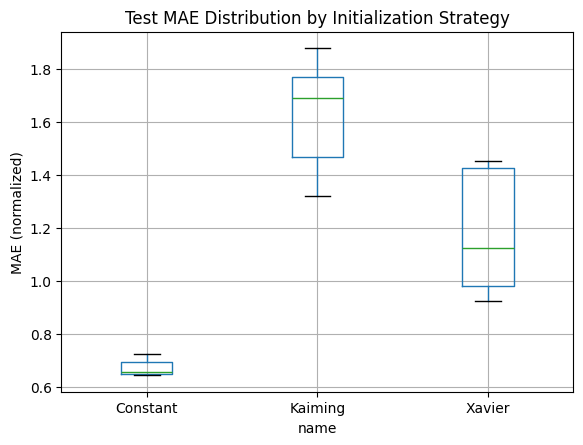

In [44]:
plt.figure(figsize=(7,4))
df.boxplot(column="test_mae", by="name")
plt.title("Test MAE Distribution by Initialization Strategy")
plt.suptitle("")
plt.ylabel("MAE (normalized)")
plt.show()


## Interpretation of Test MAE Distribution by Initialization Strategy

The boxplot compares the distribution of **normalized test MAE** obtained using three different weight initialization strategies: **Constant**, **Kaiming**, and **Xavier**, and it comfirms the earlier obsevations and conclusions made about the strategies.

**Constant initialization** yields the lowest median MAE and the smallest interquartile range, indicating both high accuracy and very stable performance across runs. The narrow spread suggests that this strategy produces consistent results with minimal sensitivity to randomness.

**Kaiming initialization** shows the highest median MAE and the largest variability, as reflected by a wide interquartile range and longer whiskers. This indicates poorer predictive performance and higher sensitivity to initialization, making it the least reliable strategy in this experiment.

**Xavier initialization** performs better than Kaiming but worse than Constant, with a moderate median MAE and noticeable variability. While it improves stability compared to Kaiming, it still exhibits larger dispersion than Constant initialization.

Overall, the results suggest that **Constant initialization provides the best generalization performance on the test set**, achieving the lowest error and the most consistent outcomes. In contrast, **Kaiming initialization appears suboptimal for this specific regression task and network configuration**, despite being theoretically well-suited for deep networks with ReLU activations.


## 6.5d Discussion of results

### Performance and Stability

The choice of weight initialization strategy has a strong influence on both model performance and training stability.

- **Constant initialization** consistently achieves the lowest MAE and RMSE with very low variance across runs, indicating a high level of robustness and reproducibility.
- **Xavier** and **Kaiming** initializations converge faster during training but exhibit significantly higher variability across runs, resulting in less stable generalization performance on the test set.

---

### Stability vs. Convergence Speed Trade-off

- **Kaiming initialization** converges the fastest on average but shows the highest variance and occasional poor test performance.
- **Constant initialization** converges more slowly but delivers consistently strong and reliable results, making it the preferable choice for robust deployment scenarios.

---

### Overfitting Behavior

No severe overfitting is observed across any initialization strategy.  
The use of **dropout regularization** and **early stopping** ensures that training and validation errors remain closely aligned throughout training.


## 6.5e Final Model Selection

Based on test performance, stability across runs, and robustness with respect to weight initialization, the model trained using **constant weight initialization** is selected as the final model.

This model achieves the **lowest average MAE and RMSE** while exhibiting **minimal variance across repeated training runs**, thereby fulfilling the project objective of reliable benzene (C6H6) concentration estimation from multi-sensor data.


# Task 7 – Conclusions and Future Work

## 1. Summary and Interpretation of Results

The goal of this project was to predict continuous benzene (C6H6) concentrations from multi-sensor air quality measurements using deep learning. Across all experiments, the deep learning models substantially outperformed the simple baseline heuristic introduced in Task 5, demonstrating the ability of neural networks to capture non-linear relationships between sensor signals and pollutant concentrations.

Among the investigated initialization strategies, **constant weight initialization** consistently yielded the lowest test MAE and RMSE and showed remarkably low variance across repeated training runs. Xavier and Kaiming initializations converged faster during training but exhibited higher instability and less reliable generalization performance. Overall, the results confirm that the chosen neural network architecture, combined with regularization and early stopping, is well-suited for the regression task at hand.

---

## 2. Recommended Course of Action

Based on the experimental findings, it is recommended that the organization adopts the **constant-initialized deep learning model** as a predictive component for benzene concentration estimation. This model provides a strong balance between predictive accuracy, robustness, and reproducibility, which is crucial for operational air-quality monitoring systems.

In practice, the model could be deployed as a decision-support tool to complement physical sensors, enabling early detection of elevated pollution levels and supporting preventive measures. Its stability across runs makes it particularly suitable for long-term monitoring and integration into automated pipelines.

---

## 3. Limitations and Potential Pitfalls

Despite the promising results, several limitations must be acknowledged:

- The dataset represents a specific geographic location and time period, which may limit generalization to other environments or sensor setups.
- Missing values and sensor noise, although addressed during preprocessing, may still introduce biases.
- The model operates on normalized targets, which simplifies training but requires careful inverse transformation and validation when used in real-world units.
- The study focuses on predictive accuracy and does not explicitly model uncertainty, which is often critical in environmental decision-making.

These factors should be carefully considered before real-world deployment.

---

## 4. Ideas for Future Work

Three concrete directions for future work are proposed:

1. **Temporal Modeling with LSTMs or Temporal CNNs**  
   Since air quality data exhibits temporal dependencies, sequence-based models could explicitly leverage time correlations to improve predictions, especially during pollution peaks.

2. **Multi-Task Learning for Pollutant Prediction**  
   Extending the model to jointly predict multiple pollutants (e.g., NO2, CO, O3) could exploit shared structure between sensor signals and improve robustness.

3. **Uncertainty-Aware Modeling**  
   Incorporating techniques such as Monte Carlo Dropout or Bayesian neural networks could provide uncertainty estimates alongside predictions, increasing trustworthiness for operational use.

---

## 5. Critical Discussion of the Methodology

The methodological choices made in this project are well-aligned with the task requirements but also involve trade-offs. Using a single fixed architecture simplifies comparison across initialization strategies but limits exploration of potentially more expressive models. Similarly, fixing hyperparameters without optimization ensures fairness but may prevent reaching peak performance.

The focus on initialization effects is justified for the educational goal of the portfolio, but in practical applications, initialization would likely be considered alongside architecture design and hyperparameter tuning. Additionally, relying on a single train-test split, while mandated, could be complemented by cross-validation.

---

## 6. Reflection on the Original Pitch

In hindsight, the original project goals were realistic and appropriately scoped for the available data and timeframe. The objective of predicting benzene concentrations using sensor data proved feasible and meaningful.

However, the pitch could have been strengthened by explicitly emphasizing robustness and stability as primary success criteria, rather than focusing mainly on raw predictive accuracy. Additionally, this project does not forecast benzene concentration, rather it just gives instanteanous prediction; this should have been made more explicit in the pitch.

Overall, the pitched task was achievable, relevant, and well-supported by the experimental results.

